In [123]:
import pandas as pd
import numpy as np
import kagglehub
import os
import requests
from bs4 import BeautifulSoup
import re, json
import h3
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import KDTree
import time
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import root_mean_squared_error
from catboost import CatBoostRegressor

In [63]:
df1 = pd.read_csv("krisha_data_raw_orig.csv")

In [64]:
df2 = pd.read_csv("krisha_data_raw.csv")

In [65]:
df_full = pd.concat([df1, df2], ignore_index=True)
len(df_full)

20022

In [66]:
df_uniq = df_full.drop_duplicates(subset='url')
len(df_uniq)

16075

In [67]:
is_all_unique = not df_uniq.duplicated().any()
is_all_unique

True

Preparation & cleaning

In [68]:
df_uniq.to_csv('df_raw.csv')

In [69]:
df_turar = pd.read_csv("Turar's code/astana_real_estate_dataset.csv")

In [70]:
df_uniq.drop(columns=['Телефон', 'Пол', 'Балкон остеклён', 'Балкон', 'Интернет', 'Дверь', 'Бывшее общежитие'], inplace=True)

In [71]:
df_uniq.notnull().mean() * 100

url                     100.000000
title                   100.000000
price                   100.000000
lat                     100.000000
lon                     100.000000
Безопасность             44.895801
Возможен обмен           96.111975
Высота потолков          91.564541
Год постройки           100.000000
Город                   100.000000
Жилой комплекс           81.144635
Квартира меблирована     50.220840
Парковка                 66.009331
Площадь                 100.000000
Санузел                  62.071540
Состояние квартиры       43.670295
Тип дома                 94.606532
Этаж                     94.886470
dtype: float64

In [72]:
df = df_uniq
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   16075 non-null  str    
 1   title                 16075 non-null  str    
 2   price                 16075 non-null  object 
 3   lat                   16075 non-null  float64
 4   lon                   16075 non-null  float64
 5   Безопасность          7217 non-null   str    
 6   Возможен обмен        15450 non-null  str    
 7   Высота потолков       14719 non-null  str    
 8   Год постройки         16075 non-null  int64  
 9   Город                 16075 non-null  str    
 10  Жилой комплекс        13044 non-null  str    
 11  Квартира меблирована  8073 non-null   str    
 12  Парковка              10611 non-null  str    
 13  Площадь               16075 non-null  str    
 14  Санузел               9978 non-null   str    
 15  Состояние квартиры    7020 non-null

In [73]:
df['rooms'] = df['title'].str.extract(r'(\d+)-комнатная').astype(float)
floor_data = df['title'].str.extract(r'(\d+)/(\d+)\s+этаж')
df['current_floor'] = floor_data[0].astype(float)
df['total_floors'] = floor_data[1].astype(float)

In [74]:
df['area_m2'] = df['Площадь'].str.extract(r'(\d+\.?\d*)').astype(float)

In [75]:
df.drop(columns='Площадь', inplace=True)
df.drop(columns='Этаж', inplace=True)

In [76]:
df['Тип дома'] = df['Тип дома'].fillna(df['Тип дома'].mode()[0])

In [77]:
df['Санузел'] = df['Санузел'].fillna(df['Санузел'].mode()[0])

In [78]:
df['Высота потолков'] = df['Высота потолков'].str.replace(r'[^\d.]', '', regex=True)
df['Высота потолков'] = df['Высота потолков'].astype(float)
mean_m = df['Высота потолков'].mean()

In [79]:
df['Высота потолков'] = df['Высота потолков'].fillna(mean_m)

In [80]:
df['Квартира меблирована'] = df['Квартира меблирована'].fillna('без мебели')
df['Состояние квартиры'] = df['Состояние квартиры'].fillna('Не указано')
df['Парковка'] = df['Парковка'].fillna('Во дворе/не указано')
df['Безопасность'] = df['Безопасность'].fillna(df['Безопасность'].mode()[0])

In [81]:
df.drop(columns='Возможен обмен', inplace=True)

In [82]:
df['current_floor'] = df['current_floor'].fillna(df['current_floor'].median())
df['total_floors'] = df['total_floors'].fillna(df['total_floors'].median())

In [83]:
df['Жилой комплекс'].fillna('Панельный дом/Не указан')

0                       Мангилик
1              Центральный сквер
2                     Sandi Qala
3                        The One
4                            Уют
                  ...           
20017                     Медина
20018    Панельный дом/Не указан
20019         Баскару 2, 3, 4, 5
20020               Prime Garden
20021    Панельный дом/Не указан
Name: Жилой комплекс, Length: 16075, dtype: str

In [84]:
# 1. Compile the regex pattern ONCE outside the function for maximum speed.
# The (?i) flag makes it completely case-insensitive.
# We use roots (e.g., 'горяч' instead of 'горячая цена') to catch all variations.
SPAM_PATTERN = re.compile(
    r'(?i)(срочн|торг|акци|уступк|цена|горяч|скидк|выгодн|упакован|ключ|дешев|рассроч|вариант|супер|тишина|евро|застрой|сдача|руки|руках|комисс|покуп|свеж|комф|класс|!!!|отлич|заезжай|живи|видовая|вариант|первая|линия|окна|бизнес)'
)

def extract_clean_address_optimized(title):
    # Safety check: Return a proper null value for ML, not a string
    if not isinstance(title, str):
        return np.nan 
        
    # Standardize all hidden formatting, tabs, and multiple spaces into a single space
    title = re.sub(r'\s+', ' ', title).strip()
    
    # Isolate the address block
    if '·' in title:
        address_block = title.split('·')[-1]
    else:
        address_block = title
        
    # Clean trailing metrics using regex
    clean_addr = re.sub(r'^.*?этаж\s*,\s*', '', address_block)
    clean_addr = re.sub(r'^.*?м²\s*,\s*', '', clean_addr)
    
    # Handle spam slogans separated by ANY type of dash or hyphen
    if re.search(r'[-—–]', clean_addr):
        # Split by the dash, accommodating variable spacing around it
        parts = re.split(r'\s*[-—–]\s*', clean_addr)
        
        if len(parts) > 1:
            # Check the right side of the dash for our compiled spam roots
            if SPAM_PATTERN.search(parts[1]):
                clean_addr = parts[0]
                
    # Final scrub of stray punctuation from the edges
    return clean_addr.strip(' ,.!?-').strip()

# Apply it to your DataFrame
df['clean_address'] = df['title'].apply(extract_clean_address_optimized)

In [85]:
valid_districts = ['Алматы', 'Есиль', 'Есильский', 'Сарыарка', 'Байконур', 'Нура', 'Сарайшык']

# 1. Strip the boilerplate text
df['Город'] = df['Город'].str.replace(r'^Астана,\s*', '', regex=True)
df['Город'] = df['Город'].str.replace(r'\s*р-н\s*', '', regex=True)

# 2. Fast vectorized replacement: If not in the whitelist, make it NaN (missing)
df.loc[~df['Город'].isin(valid_districts), 'Город'] = np.nan

# 3. Rename the column
df = df.rename(columns={'Город': 'Район'})

In [86]:
def extract_street_only_fixed(address):
    # Safety check for missing data
    if pd.isna(address) or not isinstance(address, str):
        return np.nan
        
    # 1. Normalize hidden formatting/whitespace
    street = re.sub(r'\s+', ' ', address).strip()
    
    # --- THE FIX: Aggressive Landmark / Cross-street Truncation ---
    # Split by an em/en-dash (with or without spaces) OR a standard hyphen WITH spaces.
    # We take [0] to keep ONLY the primary address on the left side.
    # This intentionally ignores unspaced hyphens so names like "Мангилик-Ел" don't break.
    street = re.split(r'\s+[-]\s+|\s*[—–]\s*', street)[0]
    # --------------------------------------------------------------
    
    # 2. Remove standard real estate boilerplate abbreviations
    boilerplate = r'(?i)\b(ул\.?|улица|пр\.?|пр-т|проспект|мкр\.?|микрорайон|пер\.?|переулок|шоссе|трасса|д\.?|дом|кв\.?)\b'
    street = re.sub(boilerplate, ' ', street)
    
    # 3. Strip trailing building numbers (e.g., " 10", ", 45/1", " 12А")
    street = re.sub(r'(?i)\s*,?\s*\d+[-/]?\d*[а-яa-z]?\b\s*$', '', street)
    
    # 4. Final scrub of stray punctuation and double spaces
    street = re.sub(r'\s+', ' ', street).strip(' ,.-/')
    
    # 5. The Numeral Street Fallback
    if not street:
         # Apply the same dash-split fix to the fallback just in case
         fallback = re.split(r'\s+[-]\s+|\s*[—–]\s*', address)[0]
         fallback = re.sub(boilerplate, ' ', fallback).strip(' ,.-/')
         return fallback if fallback else np.nan
         
    return street

# Apply it
df['street_only'] = df['clean_address'].apply(extract_street_only_fixed)

In [87]:
int_columns = ['rooms', 'current_floor', 'total_floors']
for col in int_columns:
    # errors='coerce' forces any unreadable text (like 'N/A' or 'сбой') to become NaN
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

In [88]:
df = df.rename(columns={'Безопасность': 'security', 'Высота потолков': 'ceiling_height', 'Район': 'district', 'Жилой комплекс': 'residential_complex',
                                  'Квартира меблирована': 'furnished', 'Парковка': 'parking', 'Санузел': 'bathroom_type',
                                  'Состояние квартиры': 'apartment_condition', 'Тип дома': 'building_type', 'Год постройки':'year_of_construction'})

In [89]:
df.head(5)

,url,title,price,lat,lon,security,ceiling_height,year_of_construction,district,residential_complex,...,parking,bathroom_type,apartment_condition,building_type,rooms,current_floor,total_floors,area_m2,clean_address,street_only
0,https://krisha.kz/a/show/1011890902,"2-комнатная квартира · 63 м² · 11/12 этаж, Бок...",48500000,51.090252,71.427670,"охрана, домофон, кодовый замок, видеонаблюдение",2.70,2018,Есильский,Мангилик,...,паркинг,совмещенный,свежий ремонт,монолитный,2,11,12,63.0,Бокейхана 42 — Expo - Мангилик Ел,Бокейхана
1,https://krisha.kz/a/show/1011872179,"2-комнатная квартира · 59 м² · 2/9 этаж, Ахмет...",38500000,51.116968,71.505137,"охрана, кодовый замок, видеонаблюдение, видеод...",3.00,2023,Сарайшык,Центральный сквер,...,рядом охраняемая стоянка,совмещенный,свежий ремонт,монолитный,2,2,9,59.0,Ахмет Байтурсынулы 14/3 — Аллея Мынжылдык,Ахмет Байтурсынулы
2,https://krisha.kz/a/show/1010675410,"2-комнатная квартира · 50 м² · 14/19 этаж, Жош...",44000000,51.101315,71.439466,"охрана, кодовый замок, видеонаблюдение, видеод...",3.00,2025,Есильский,Sandi Qala,...,паркинг,совмещенный,свежий ремонт,монолитный,2,14,19,50.0,Жошы Хана 12 — Сфера Парк,Жошы Хана
3,https://krisha.kz/a/show/1012729246,"4-комнатная квартира · 225 м² · 5/18 этаж, Дин...",300000000,51.129934,71.424512,"домофон, видеонаблюдение",3.55,2024,Есильский,The One,...,паркинг,совмещенный,Не указано,монолитный,4,5,18,225.0,Динмухамеда Кунаева 8а,Динмухамеда Кунаева
4,https://krisha.kz/a/show/1009888824,"3-комнатная квартира · 88 м² · 8/10 этаж, Сыга...",42900000,51.121237,71.431714,видеонаблюдение,2.80,2010,Есильский,Уют,...,паркинг,совмещенный,Не указано,монолитный,3,8,10,88.0,Сыганак 64/1 — Сыганак- Туркестан,Сыганак


In [90]:
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   16075 non-null  str    
 1   title                 16075 non-null  str    
 2   price                 16075 non-null  object 
 3   lat                   16075 non-null  float64
 4   lon                   16075 non-null  float64
 5   security              16075 non-null  str    
 6   ceiling_height        16075 non-null  float64
 7   year_of_construction  16075 non-null  int64  
 8   district              15513 non-null  str    
 9   residential_complex   13044 non-null  str    
 10  furnished             16075 non-null  str    
 11  parking               16075 non-null  str    
 12  bathroom_type         16075 non-null  str    
 13  apartment_condition   16075 non-null  str    
 14  building_type         16075 non-null  str    
 15  rooms                 16075 non-nul

In [91]:
def generate_h3_features(df, lat_col='lat', lon_col='lon'):
    # Create a copy to avoid SettingWithCopy warnings
    df_spatial = df.copy()
    
    # Define our resolutions. 
    # We use 7, 8, and 9 as they are perfect for city-level real estate.
    resolutions = [7, 8, 9]
    
    for res in resolutions:
        col_name = f'h3_res_{res}'
        
        # We use a lambda function to apply the H3 conversion row by row.
        # h3.latlng_to_cell is the modern v4 API standard (formerly geo_to_h3).
        df_spatial[col_name] = df_spatial.apply(
            lambda row: h3.latlng_to_cell(row[lat_col], row[lon_col], res) 
            if pd.notnull(row[lat_col]) and pd.notnull(row[lon_col]) 
            else np.nan, 
            axis=1
        )
        
    return df_spatial

# Apply the function to your DataFrame
df = generate_h3_features(df)

In [92]:
# 1. Clean the column and handle NaN values gracefully
# If a row is NaN or empty, we fill it with an empty string so the split doesn't crash
df['security_cleaned'] = df['security'].astype(str).str.lower().fillna('')

# 2. Calculate the total number of security features
# We split by the comma. If the string is empty, the count should be 0.
df['security_count'] = df['security_cleaned'].apply(
    lambda x: len([item for item in x.split(',') if item.strip()]) if x.strip() and x != 'nan' else 0
)

# 3. Drop the temporary cleaning column
df = df.drop(columns=['security_cleaned'])

# Check the distribution of your new feature
print(df['security_count'].value_counts())

security_count
2    11125
3     1573
4     1115
1      926
5      693
6      442
7      167
8       34
Name: count, dtype: int64


In [93]:
# 1. Convert to string and lowercase to avoid treating 'Охрана' and 'охрана' differently
clean_strings = df['security'].astype(str).str.lower()

# 2. The Chain: Split -> Explode -> Strip -> Unique
unique_features = (
    clean_strings
    .str.split(',')       # Turns "охрана, домофон" into a list: ["охрана", " домофон"]
    .explode()            # Takes the list and creates a new row for each item
    .str.strip()          # Removes the accidental spaces (turns " домофон" into "домофон")
    .unique()             # Extracts only the distinct, unique values
)

# 3. Clean up the final array by removing empty strings or 'nan'
unique_features = [f for f in unique_features if f and f != 'nan']

print(f"Total unique features found: {len(unique_features)}")
print(unique_features)

Total unique features found: 8
['охрана', 'домофон', 'кодовый замок', 'видеонаблюдение', 'видеодомофон', 'сигнализация', 'решетки на окнах', 'консьерж']


In [94]:
# Предположим, что ваш исходный столбец называется 'security'
# 1. Очищаем данные: переводим в нижний регистр и убираем случайные пробелы по краям
df['security'] = df['security'].astype(str).str.lower().str.strip()

# 2. Превращаем текстовую строку в матрицу бинарных признаков (0 и 1)
# Разделителем указываем запятую и пробел ', '
security_dummies = df['security'].str.get_dummies(sep=', ')

# 3. Добавляем понятный префикс к названиям новых колонок, чтобы не запутаться
security_dummies = security_dummies.add_prefix('sec_')

# Посмотрим, какие колонки у нас получились (например: sec_охрана, sec_домофон)
print("Созданные признаки:", security_dummies.columns.tolist())

Созданные признаки: ['sec_видеодомофон', 'sec_видеонаблюдение', 'sec_домофон', 'sec_кодовый замок', 'sec_консьерж', 'sec_охрана', 'sec_решетки на окнах', 'sec_сигнализация']


In [95]:
# 4. Объединяем новые колонки с основным датафреймом и удаляем старый текстовый столбец
df = pd.concat([df, security_dummies], axis=1)
df = df.drop(columns=['security'])

In [96]:
park_coords = np.array([
    [51.1577, 71.420],  # Central Park
    [51.137, 71.444],  # Jetysu Park
    [51.126, 71.464],  # Presidential Park
    [51.134, 71.455],  # Astana Triathlon Park
    [51.132, 71.413],  # Lovers Park
    [51.119, 71.426],  # Linear Park
    [51.113, 71.441],  # First President Park
    [51.102, 71.447],  # Samal Park
    [51.152, 71.433],  # Ataturk Park
    [51.107, 71.418],  # Botanical garden
])

mall_coords = np.array([
    [51.133, 71.404],  # Khan Shatyr
    [51.090, 71.408],  # MEGA Silk Way
    [51.144, 71.478],  # Astana Mall
    [51.128, 71.425],  # Keruen
    [51.129, 71.414],  # Asia Park
    [51.147, 71.421],  # KeruenCity
    [51.150, 71.480],  # Eurasia
    [51.125, 71.444],  # Abu-Dhabi Plaza
    [51.142, 71.423],  # Saryarka
])

# lrt_coords = np.array([
#     lrt_coords = np.array([
#     [51.049, 71.431],  # Esil
#     [51.056, 71.419],  # Mangilik El
#     [51.076, 71.406],  # Astana Juldyzy 
#     [51.081, 71.400],  # 106 Nura
#     [51.091, 71.406],  # 107 University
#     [51.100, 71.406],  # 108 Uly Dala
#     [51.109, 71.414],  # 109 Astana Arena
#     [51.????, 71.????],  # 110 Martial Arts Palace
#     [51.????, 71.????],  # 111 Syganaq
#     [51.????, 71.????],  # 112 Baiterek
#     [51.????, 71.????],  # 113 House of Ministries
#     [51.????, 71.????],  # 114 National Museum
#     [51.????, 71.????],  # 115 Theatre
#     [51.????, 71.????],  # 116 Mynjyldyq Alley
#     [51.????, 71.????],  # 117 Jibek Joly
#     [51.1124, 71.5318],  # 118 Nurly Jol (confirmed)
# ])
# ])

In [97]:
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   16075 non-null  str    
 1   title                 16075 non-null  str    
 2   price                 16075 non-null  object 
 3   lat                   16075 non-null  float64
 4   lon                   16075 non-null  float64
 5   ceiling_height        16075 non-null  float64
 6   year_of_construction  16075 non-null  int64  
 7   district              15513 non-null  str    
 8   residential_complex   13044 non-null  str    
 9   furnished             16075 non-null  str    
 10  parking               16075 non-null  str    
 11  bathroom_type         16075 non-null  str    
 12  apartment_condition   16075 non-null  str    
 13  building_type         16075 non-null  str    
 14  rooms                 16075 non-null  Int64  
 15  current_floor         16075 non-nul

In [98]:
# Create a temporary numeric column to find the failures
temp_numeric = pd.to_numeric(df['price'], errors='coerce')

# Look at the original values for rows that turned into NaN
corrupted_prices = df[temp_numeric.isna()]['price']
print(corrupted_prices.unique()[:20])  # Prints the first 20 unique problem values

['от 52260500' 'от 34405560' 'от 48698800' 'от 43053120' 'от 87765600'
 'от 53109300' 'от 37828650' 'от 39585670' 'от 80658360' 'от 70451850'
 'от 88665210' 'от 128251250' 'от 57804210' 'от 45146660' 'от 27112300'
 'от 13320000' 'от 39943200' 'от 159354750' 'от 36879360' 'от 20139900']


In [99]:
# 1. Remove 'от' and any surrounding whitespace
df['price'] = df['price'].astype(str).str.replace('от', '', regex=False)
df['price'] = df['price'].str.strip()

# 2. Convert to numeric safely
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 3. Check your row count now—it should be back to 16075!
print("Valid rows after fix:", df['price'].notna().sum())

Valid rows after fix: 16075


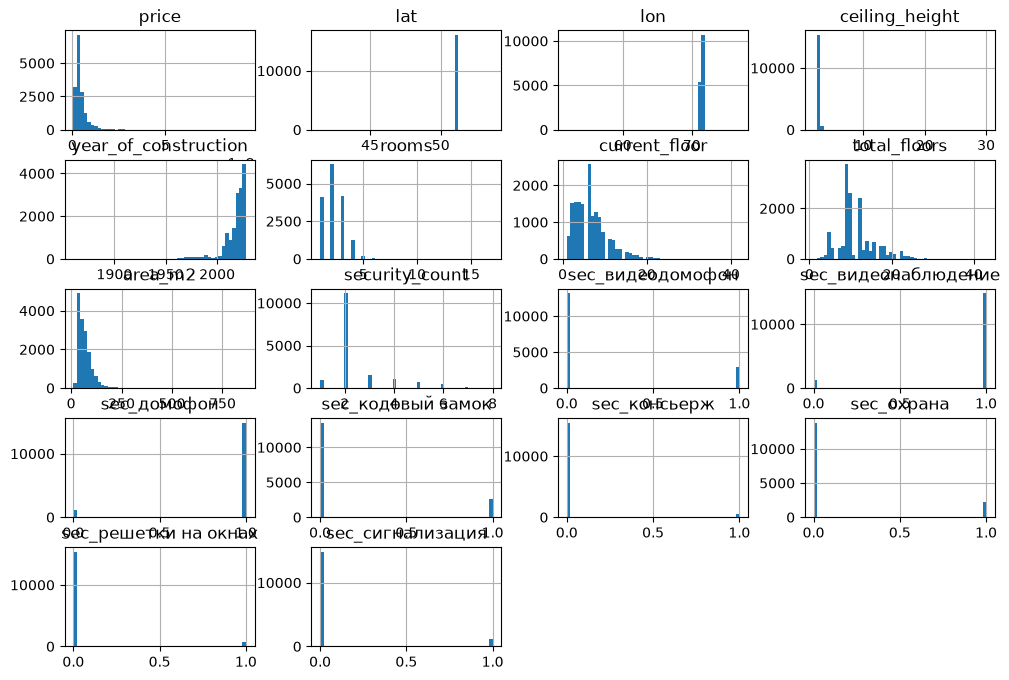

In [100]:
df.hist(bins = 50, figsize = (12, 8))
plt.show()

<Axes: xlabel='price', ylabel='Count'>

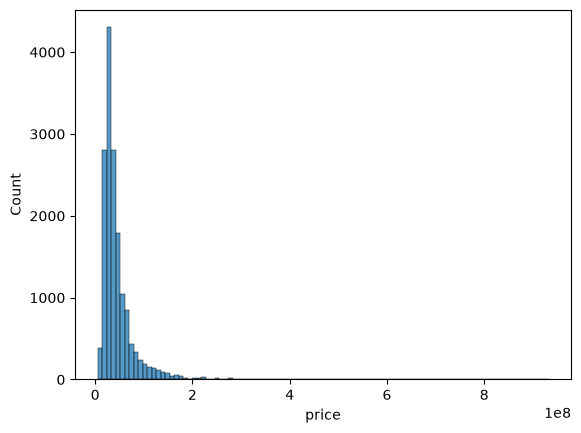

In [101]:
sns.histplot(df.price, bins = 100)

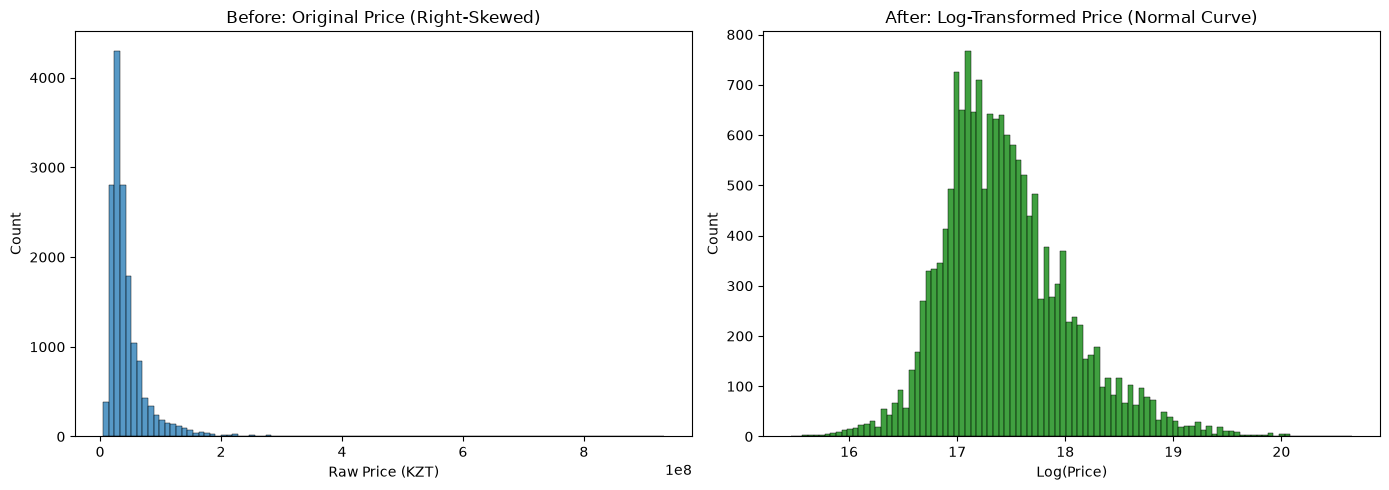

In [102]:
df['price_log'] = np.log1p(df['price'])

# 2. Visualizing the Difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Your original skewed data
sns.histplot(df['price'], bins=100, ax=axes[0])
axes[0].set_title('Before: Original Price (Right-Skewed)')
axes[0].set_xlabel('Raw Price (KZT)')

# Plot 2: The transformed data
sns.histplot(df['price_log'], bins=100, ax=axes[1], color='green')
axes[1].set_title('After: Log-Transformed Price (Normal Curve)')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

In [103]:
df.head(5)

,url,title,price,lat,lon,ceiling_height,year_of_construction,district,residential_complex,furnished,...,security_count,sec_видеодомофон,sec_видеонаблюдение,sec_домофон,sec_кодовый замок,sec_консьерж,sec_охрана,sec_решетки на окнах,sec_сигнализация,price_log
0,https://krisha.kz/a/show/1011890902,"2-комнатная квартира · 63 м² · 11/12 этаж, Бок...",48500000,51.090252,71.427670,2.70,2018,Есильский,Мангилик,полностью,...,4,0,1,1,1,0,1,0,0,17.697074
1,https://krisha.kz/a/show/1011872179,"2-комнатная квартира · 59 м² · 2/9 этаж, Ахмет...",38500000,51.116968,71.505137,3.00,2023,Сарайшык,Центральный сквер,полностью,...,4,1,1,0,1,0,1,0,0,17.466169
2,https://krisha.kz/a/show/1010675410,"2-комнатная квартира · 50 м² · 14/19 этаж, Жош...",44000000,51.101315,71.439466,3.00,2025,Есильский,Sandi Qala,полностью,...,4,1,1,0,1,0,1,0,0,17.599700
3,https://krisha.kz/a/show/1012729246,"4-комнатная квартира · 225 м² · 5/18 этаж, Дин...",300000000,51.129934,71.424512,3.55,2024,Есильский,The One,без мебели,...,2,0,1,1,0,0,0,0,0,19.519293
4,https://krisha.kz/a/show/1009888824,"3-комнатная квартира · 88 м² · 8/10 этаж, Сыга...",42900000,51.121237,71.431714,2.80,2010,Есильский,Уют,без мебели,...,1,0,1,0,0,0,0,0,0,17.574382


In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   16075 non-null  str    
 1   title                 16075 non-null  str    
 2   price                 16075 non-null  int64  
 3   lat                   16075 non-null  float64
 4   lon                   16075 non-null  float64
 5   ceiling_height        16075 non-null  float64
 6   year_of_construction  16075 non-null  int64  
 7   district              15513 non-null  str    
 8   residential_complex   13044 non-null  str    
 9   furnished             16075 non-null  str    
 10  parking               16075 non-null  str    
 11  bathroom_type         16075 non-null  str    
 12  apartment_condition   16075 non-null  str    
 13  building_type         16075 non-null  str    
 14  rooms                 16075 non-null  Int64  
 15  current_floor         16075 non-nul

In [105]:
df['district'].isna().sum()

np.int64(562)

In [106]:
df[df['district'].isna()]

,url,title,price,lat,lon,ceiling_height,year_of_construction,district,residential_complex,furnished,...,security_count,sec_видеодомофон,sec_видеонаблюдение,sec_домофон,sec_кодовый замок,sec_консьерж,sec_охрана,sec_решетки на окнах,sec_сигнализация,price_log
27,https://krisha.kz/a/show/1011827687,"2-комнатная квартира · 80.82 м², Нура р-н",80658360,51.136692,71.388263,3.000000,2027,NaN,Greenline. Tiara,без мебели,...,2,0,1,1,0,0,0,0,0,18.205733
72,https://krisha.kz/a/show/1012410433,"3-комнатная квартира · 94 м² · 11/12 этаж, Бай...",58200000,51.117720,71.509966,2.900000,2023,NaN,Bai-Tursyn,полностью,...,6,0,1,1,1,0,1,1,1,17.879396
111,https://krisha.kz/a/show/1009826828,"2-комнатная квартира · 42 м² · 3/19 этаж, Буха...",34500000,51.101168,71.439706,3.000000,2025,NaN,Sandi Qala,полностью,...,3,1,1,0,1,0,0,0,0,17.356470
201,https://krisha.kz/a/show/1011827769,"3-комнатная квартира · 118.18 м², Нура р-н",110616480,51.136692,71.388263,3.000000,2027,NaN,Greenline. Tiara,без мебели,...,2,0,1,1,0,0,0,0,0,18.521580
248,https://krisha.kz/a/show/1012376197,"2-комнатная квартира · 65 м² · 8/20 этаж, ул. ...",32200000,51.115893,71.499956,3.000000,2025,NaN,A-City,частично,...,1,0,0,1,0,0,0,0,0,17.287477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19933,https://krisha.kz/a/show/1010867575,"5-комнатная квартира · 215 м² · 3/5 этаж, Сейф...",117480052,51.168413,71.403264,2.897472,2000,NaN,NaN,без мебели,...,2,0,1,1,0,0,0,0,0,18.581779
19939,https://krisha.kz/a/show/1006753539,"2-комнатная квартира · 57.78 м² · 9/17 этаж, А...",58000000,51.102520,71.450931,3.000000,2026,NaN,Capital Park. Art,без мебели,...,2,0,1,1,0,0,0,0,0,17.875954
19946,https://krisha.kz/a/show/1011577061,"2-комнатная квартира · 47.49 м² · 8/12 этаж, Т...",30500000,51.080007,71.431158,3.000000,2026,NaN,MoD. Style,без мебели,...,2,0,1,1,0,0,0,0,0,17.233237
19948,https://krisha.kz/a/show/1011075334,"3-комнатная квартира · 89.14 м² · 5/9 этаж, Бу...",60000000,51.105840,71.389565,3.000000,2026,NaN,Arena Style,без мебели,...,2,0,1,1,0,0,0,0,0,17.909855


In [107]:
df['residential_complex'].isna().sum()

np.int64(3031)

In [108]:
df['residential_complex'] = df['residential_complex'].fillna('Панельный дом/Не указан')

In [109]:
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   16075 non-null  str    
 1   title                 16075 non-null  str    
 2   price                 16075 non-null  int64  
 3   lat                   16075 non-null  float64
 4   lon                   16075 non-null  float64
 5   ceiling_height        16075 non-null  float64
 6   year_of_construction  16075 non-null  int64  
 7   district              15513 non-null  str    
 8   residential_complex   16075 non-null  str    
 9   furnished             16075 non-null  str    
 10  parking               16075 non-null  str    
 11  bathroom_type         16075 non-null  str    
 12  apartment_condition   16075 non-null  str    
 13  building_type         16075 non-null  str    
 14  rooms                 16075 non-null  Int64  
 15  current_floor         16075 non-nul

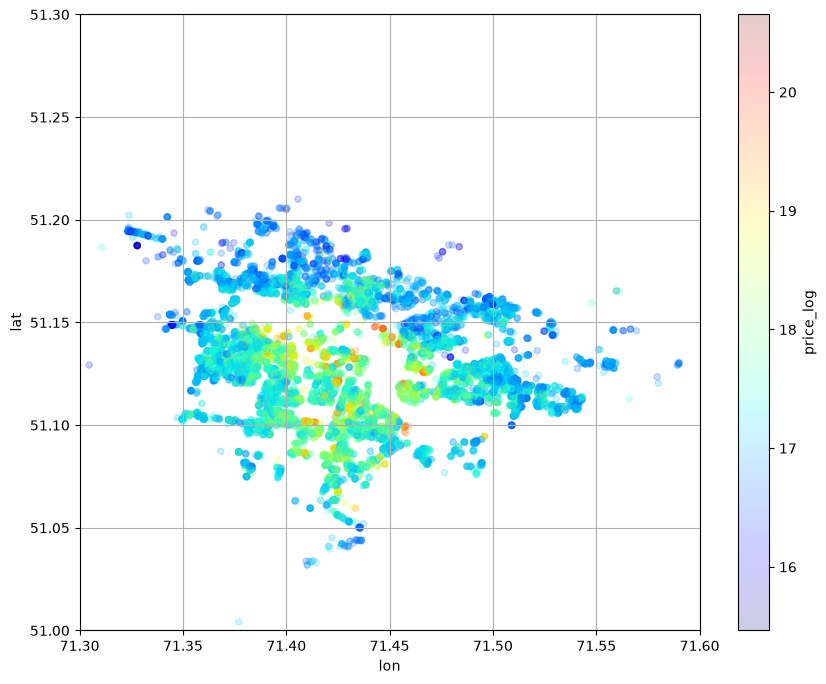

In [113]:
df.plot(kind = "scatter", x = "lon", y = "lat", grid = True, alpha = 0.2, figsize=(10, 8), c="price_log", cmap="jet", colorbar=True,)
plt.xlim(71.3, 71.6)
plt.ylim(51.0, 51.3)
plt.show()

In [116]:
meta_columns = ['url', 'title', 'price', 'lat', 'lon']

# 2. Save them to a new DataFrame (using .copy() so it's fully independent)
df_meta = df[meta_columns].copy()

# 3. Drop them from your main training DataFrame
df = df.drop(columns=meta_columns)

df_meta.to_csv('df_meta.csv')
# --- HOW TO REJOIN THEM LATER ---
# Because both dataframes still share the same original index numbers,
# you can instantly snap them back together using .join()
# 
# df_combined = df.join(df_meta)

In [117]:
df.head()

,ceiling_height,year_of_construction,district,residential_complex,furnished,parking,bathroom_type,apartment_condition,building_type,rooms,...,security_count,sec_видеодомофон,sec_видеонаблюдение,sec_домофон,sec_кодовый замок,sec_консьерж,sec_охрана,sec_решетки на окнах,sec_сигнализация,price_log
0,2.70,2018,Есильский,Мангилик,полностью,паркинг,совмещенный,свежий ремонт,монолитный,2,...,4,0,1,1,1,0,1,0,0,17.697074
1,3.00,2023,Сарайшык,Центральный сквер,полностью,рядом охраняемая стоянка,совмещенный,свежий ремонт,монолитный,2,...,4,1,1,0,1,0,1,0,0,17.466169
2,3.00,2025,Есильский,Sandi Qala,полностью,паркинг,совмещенный,свежий ремонт,монолитный,2,...,4,1,1,0,1,0,1,0,0,17.599700
3,3.55,2024,Есильский,The One,без мебели,паркинг,совмещенный,Не указано,монолитный,4,...,2,0,1,1,0,0,0,0,0,19.519293
4,2.80,2010,Есильский,Уют,без мебели,паркинг,совмещенный,Не указано,монолитный,3,...,1,0,1,0,0,0,0,0,0,17.574382


In [118]:
apt_coords_rad = np.radians(df_meta[['lat', 'lon']].values)
malls_rad = np.radians(mall_coords)
parks_rad = np.radians(park_coords)

# 3. Build the BallTrees
print("Building spherical distance trees for Malls and Parks...")
mall_tree = BallTree(malls_rad, metric='haversine')
park_tree = BallTree(parks_rad, metric='haversine')

EARTH_RADIUS_KM = 6371.0

# --- STRATEGY 1: DISTANCE TO NEAREST ---
print("Calculating exact distance to nearest amenities...")
mall_dists_rad, _ = mall_tree.query(apt_coords_rad, k=1)
park_dists_rad, _ = park_tree.query(apt_coords_rad, k=1)

# Convert from radians back to kilometers and add to main df
df['dist_to_nearest_mall_km'] = (mall_dists_rad * EARTH_RADIUS_KM).flatten()
df['dist_to_nearest_park_km'] = (park_dists_rad * EARTH_RADIUS_KM).flatten()

Building spherical distance trees for Malls and Parks...
Calculating exact distance to nearest amenities...


In [120]:
df.info()

<class 'pandas.DataFrame'>
Index: 16075 entries, 0 to 20021
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ceiling_height           16075 non-null  float64
 1   year_of_construction     16075 non-null  int64  
 2   district                 15513 non-null  str    
 3   residential_complex      16075 non-null  str    
 4   furnished                16075 non-null  str    
 5   parking                  16075 non-null  str    
 6   bathroom_type            16075 non-null  str    
 7   apartment_condition      16075 non-null  str    
 8   building_type            16075 non-null  str    
 9   rooms                    16075 non-null  Int64  
 10  current_floor            16075 non-null  Int64  
 11  total_floors             16075 non-null  Int64  
 12  area_m2                  16075 non-null  float64
 13  clean_address            16075 non-null  str    
 14  street_only              16075 non-nul

In [121]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["price_log"].sort_values(ascending=False)

price_log                  1.000000
area_m2                    0.823425
rooms                      0.762093
year_of_construction       0.251633
total_floors               0.216281
security_count             0.202694
sec_охрана                 0.192066
sec_видеодомофон           0.182775
sec_консьерж               0.161494
current_floor              0.138652
sec_кодовый замок          0.133682
ceiling_height             0.112707
sec_сигнализация           0.081773
sec_видеонаблюдение        0.047817
sec_решетки на окнах       0.021015
dist_to_nearest_mall_km   -0.015721
dist_to_nearest_park_km   -0.018269
sec_домофон               -0.068604
Name: price_log, dtype: float64

In [126]:
#Splitting
df_full_train, df_test = train_test_split(df, test_size=0.15, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=15/85, random_state=11)

In [127]:
len(df_train), len(df_val), len(df_test)

(11251, 2412, 2412)

In [128]:
df_train = df_train.dropna(subset=['district'])
df_val = df_val.dropna(subset=['district'])
df_test = df_test.dropna(subset=['district'])

In [129]:
# 1. Extract the target values into separate variables
y_train = df_train['price_log'].values
y_val = df_val['price_log'].values
y_test = df_test['price_log'].values

# 2. Delete the target column from the feature dataframes
del df_train['price_log']
del df_val['price_log']
del df_test['price_log']

In [57]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')

dv = DictVectorizer(sparse=True)

# Fit on training data and transform all sets
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

In [58]:
# --- 2. Training the Ridge Model ---
# alpha is the regularization strength parameter (higher means more regularization)
alpha_value = 1.0  
ridge_model = Ridge(alpha=alpha_value, random_state=11)
ridge_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",11
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

In [59]:
# --- 3. Validation Evaluation ---
# Predict on the validation set (outputs will be on the log scale)
y_pred_val_log = ridge_model.predict(X_val)

# Convert back to actual prices if you want to calculate true dollar-amount errors
y_pred_val = np.expm1(y_pred_val_log)
y_val_actual = np.expm1(y_val)

# Calculate RMSE on the log scale (standard practice for log-transformed targets)
rmse_val = root_mean_squared_error(y_val, y_pred_val_log)
print(f"Validation Log RMSE: {rmse_val:.4f}")

Validation Log RMSE: 0.1601


In [60]:
# --- 4. Final Test Evaluation ---
# Predict on the test set
y_pred_test_log = ridge_model.predict(X_test)

# Calculate RMSE on the test set
rmse_test = root_mean_squared_error(y_test, y_pred_test_log)
print(f"Test Log RMSE:       {rmse_test:.4f}")

Test Log RMSE:       0.1692


In [ ]:
#CatBoost

In [130]:
categorical_features = list(df_train.select_dtypes(include=['object', 'category']).columns)

print(f"Detected categorical columns: {categorical_features}")

Detected categorical columns: ['district', 'residential_complex', 'furnished', 'parking', 'bathroom_type', 'apartment_condition', 'building_type', 'clean_address', 'street_only', 'h3_res_7', 'h3_res_8', 'h3_res_9']


/tmp/ipykernel_92666/3628869195.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = list(df_train.select_dtypes(include=['object', 'category']).columns)


In [131]:
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=11,
    verbose=100 # Prints progress every 100 trees so you can see it training
)

# Train the model by explicitly passing the categorical feature indices/names
cb_model.fit(
    df_train, y_train,
    cat_features=categorical_features,
    eval_set=(df_val, y_val),
    early_stopping_rounds=50 # Stops early if validation error stops improving
)

0:	learn: 0.5524488	test: 0.5634568	best: 0.5634568 (0)	total: 74.8ms	remaining: 37.3s
100:	learn: 0.1604956	test: 0.1609862	best: 0.1609862 (100)	total: 2.71s	remaining: 10.7s
200:	learn: 0.1453225	test: 0.1478743	best: 0.1478743 (200)	total: 5.25s	remaining: 7.8s
300:	learn: 0.1371925	test: 0.1414650	best: 0.1414650 (300)	total: 7.65s	remaining: 5.06s
400:	learn: 0.1309752	test: 0.1374482	best: 0.1374482 (400)	total: 10.1s	remaining: 2.5s
499:	learn: 0.1259515	test: 0.1342526	best: 0.1342513 (498)	total: 12.9s	remaining: 0us

bestTest = 0.1342512825
bestIteration = 498

Shrink model to first 499 iterations.


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=11, verbose=100)

In [132]:
# --- 3. Evaluate on Validation and Test Sets ---
# Predict (outputs are on the log scale)
y_pred_val_log = cb_model.predict(df_val)
y_pred_test_log = cb_model.predict(df_test)

# Calculate RMSE
rmse_val = root_mean_squared_error(y_val, y_pred_val_log)
rmse_test = root_mean_squared_error(y_test, y_pred_test_log)

print("\n--- CatBoost Performance ---")
print(f"Validation Log RMSE: {rmse_val:.4f}")
print(f"Test Log RMSE:       {rmse_test:.4f}")


--- CatBoost Performance ---
Validation Log RMSE: 0.1343
Test Log RMSE:       0.1457


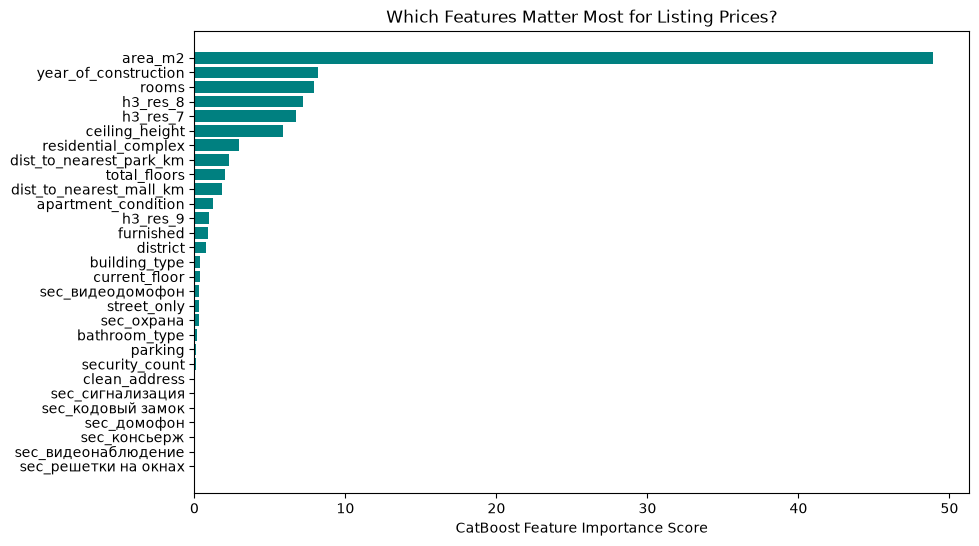

In [133]:
# Get feature importance from CatBoost
importance = cb_model.get_feature_importance()
feature_names = df_train.columns

# Create a dataframe for easy plotting
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot the results
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='teal')
plt.xlabel('CatBoost Feature Importance Score')
plt.title('Which Features Matter Most for Listing Prices?')
plt.show()